In [1]:
from __future__ import annotations

import os
import glob
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset


# =========================================================
# Unicode -> class id
# =========================================================

HIRAGANA_RANGE = (0x3040, 0x309F)
KATAKANA_RANGE = (0x30A0, 0x30FF)


def parse_unicode_cell(u: object) -> Optional[int]:
    """
    DataFrameの 'Unicode' セルが以下のどれでも int codepoint にする:
      - "U+3042" 形式
      - "3042"   形式
      - "あ"     1文字
      - NaN / None -> None
    """
    if u is None:
        return None
    if isinstance(u, float) and pd.isna(u):
        return None

    s = str(u).strip()
    if not s:
        return None

    # "U+3042"
    if s.upper().startswith("U+"):
        try:
            return int(s[2:], 16)
        except ValueError:
            return None

    # "3042" (hexっぽい)
    if all(c in "0123456789abcdefABCDEF" for c in s) and len(s) in (4, 5, 6):
        try:
            return int(s, 16)
        except ValueError:
            pass

    # "あ" のような 1 文字
    if len(s) == 1:
        return ord(s)

    return None


def is_kana(codepoint: int) -> bool:
    return (HIRAGANA_RANGE[0] <= codepoint <= HIRAGANA_RANGE[1]) or (
        KATAKANA_RANGE[0] <= codepoint <= KATAKANA_RANGE[1]
    )


# =========================================================
# Mask generation (bbox only)
# =========================================================

def _clip_xyxy(x1: int, y1: int, x2: int, y2: int, W: int, H: int) -> Tuple[int, int, int, int]:
    x1 = max(0, min(x1, W))
    x2 = max(0, min(x2, W))
    y1 = max(0, min(y1, H))
    y2 = max(0, min(y2, H))
    return x1, y1, x2, y2


def make_text_region_mask(
    ann_df: pd.DataFrame,
    H: int,
    W: int,
    *,
    x_col: str = "X",
    y_col: str = "Y",
    w_col: str = "Width",
    h_col: str = "Height",
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    本文領域マスク: bbox領域を 1 とする 2値マスク (H, W)
    """
    mask = torch.zeros((H, W), dtype=dtype)
    if ann_df is None or len(ann_df) == 0:
        return mask

    for _, row in ann_df.iterrows():
        x = int(row[x_col])
        y = int(row[y_col])
        w = int(row[w_col])
        h = int(row[h_col])

        x1, y1 = x, y
        x2, y2 = x + w, y + h
        x1, y1, x2, y2 = _clip_xyxy(x1, y1, x2, y2, W, H)
        if x1 < x2 and y1 < y2:
            mask[y1:y2, x1:x2] = 1.0
    return mask


def make_affinity_mask(
    ann_df: pd.DataFrame,
    H: int,
    W: int,
    *,
    expand_ratio_y: float = 0.2,
    x_col: str = "X",
    y_col: str = "Y",
    w_col: str = "Width",
    h_col: str = "Height",
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    アフィニティマスク:
      - bboxを縦方向に expand_ratio_y だけ上下に拡張
      - 拡張bbox同士の重なり領域を 1 とする

    実装は count-map を作って (count>=2) を affinity とする（O(N)描画 + threshold）。
    """
    if ann_df is None or len(ann_df) == 0:
        return torch.zeros((H, W), dtype=dtype)

    count = torch.zeros((H, W), dtype=torch.int16)

    for _, row in ann_df.iterrows():
        x = int(row[x_col])
        y = int(row[y_col])
        w = int(row[w_col])
        h = int(row[h_col])

        dy = int(round(h * expand_ratio_y))

        x1 = x
        x2 = x + w
        y1 = y - dy
        y2 = y + h + dy

        x1, y1, x2, y2 = _clip_xyxy(x1, y1, x2, y2, W, H)
        if x1 < x2 and y1 < y2:
            count[y1:y2, x1:x2] += 1

    affinity = (count >= 2).to(dtype)
    return affinity


def make_final_text_mask(text_region_mask: torch.Tensor, affinity_mask: torch.Tensor) -> torch.Tensor:
    """
    final_text_mask = text_region_mask - affinity_mask を 2値化して返す
    """
    final = (text_region_mask - affinity_mask).clamp(min=0.0)
    final = (final > 0.5).to(text_region_mask.dtype)
    return final


# =========================================================
# Pixel-level one-hot label map
# =========================================================

def make_one_hot_char_label_map(
    ann_df: pd.DataFrame,
    H: int,
    W: int,
    mapper: UnicodeClassMapper,
    *,
    unicode_col: str = "Unicode",
    x_col: str = "X",
    y_col: str = "Y",
    w_col: str = "Width",
    h_col: str = "Height",
    affinity_mask: Optional[torch.Tensor] = None,
    mask_out_affinity: bool = True,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    ピクセル単位 one-hot 文字種ラベルマップ: (H, W, C)
      - bbox領域に該当クラスを 1
      - mask_out_affinity=True の場合、affinity領域は 0 に戻す（曖昧領域の除外）
    """
    C = mapper.num_classes
    label = torch.zeros((H, W, C), dtype=dtype)

    if ann_df is None or len(ann_df) == 0:
        return label

    for _, row in ann_df.iterrows():
        x = int(row[x_col])
        y = int(row[y_col])
        w = int(row[w_col])
        h = int(row[h_col])
        cls = mapper.to_class_id(row.get(unicode_col, None))

        x1, y1 = x, y
        x2, y2 = x + w, y + h
        x1, y1, x2, y2 = _clip_xyxy(x1, y1, x2, y2, W, H)
        if x1 < x2 and y1 < y2:
            # 重なりがあっても最大値で 1 を保持
            label[y1:y2, x1:x2, cls] = 1.0

    if mask_out_affinity and affinity_mask is not None:
        # affinity領域の全チャネルを 0
        am = affinity_mask.to(dtype)  # (H, W)
        label[am > 0.5] = 0.0

    return label


# =========================================================
# Image / annotation loading (project structure: folder/images + folder/*.csv)
# =========================================================

def list_folders(root_dir: str) -> List[str]:
    return [
        name for name in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, name))
    ]


def load_doc_csv(doc_dir: str) -> pd.DataFrame:
    csv_files = glob.glob(os.path.join(doc_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"CSV not found in: {doc_dir}")
    return pd.read_csv(csv_files[0], encoding="utf-8")


def list_images(images_dir: str) -> List[str]:
    return [
        name for name in os.listdir(images_dir)
        if os.path.isfile(os.path.join(images_dir, name))
    ]


def image_id_from_filename(name: str) -> str:
    # "xxxx.png" -> "xxxx"
    return os.path.splitext(name)[0]

def load_and_resize_pad_image(
    image_path: str,
    *,
    target_width: int,   # ここでは「長辺の目標長さ」として使う
    patch_size: int = 256,
) -> Tuple[torch.Tensor, int, int, int, int]:
    """
    画像を読み込み:
      - 長辺が target_width になるように等倍スケール（縦横比維持）
      - 短辺を patch_size の倍数にするためにゼロパディング（右 or 下）
    return:
      img: (3, H_pad, W_pad) float32 [0..1]
      orig_w, orig_h, new_w, new_h (new_* はパディング前のリサイズ後サイズ)
    """
    img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = img.size

    # 長辺を target_width に合わせる（縦横比維持）
    long_side = max(orig_w, orig_h)
    scale = float(target_width) / float(long_side)
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))
    new_w = max(new_w, 1)
    new_h = max(new_h, 1)

    try:
        resample = Image.Resampling.BILINEAR
    except AttributeError:
        resample = Image.BILINEAR

    img = img.resize((new_w, new_h), resample)

    # 短辺だけ patch_size の倍数にパディング
    if new_w <= new_h:
        # 幅が短辺
        padded_w = ((new_w + patch_size - 1) // patch_size) * patch_size
        padded_h = new_h
    else:
        # 高さが短辺
        padded_w = new_w
        padded_h = ((new_h + patch_size - 1) // patch_size) * patch_size

    if padded_w != new_w or padded_h != new_h:
        padded = Image.new("RGB", (padded_w, padded_h), (0, 0, 0))
        padded.paste(img, (0, 0))  # 左上に貼る（右/下がゼロパディング）
        img = padded

    t = torch.from_numpy(__import__("numpy").array(img)).permute(2, 0, 1).float() / 255.0
    return t, orig_w, orig_h, new_w, new_h

def scale_annotation_df(
    ann_df: pd.DataFrame,
    *,
    scale: float,
    x_col: str = "X",
    y_col: str = "Y",
    w_col: str = "Width",
    h_col: str = "Height",
) -> pd.DataFrame:
    """bboxを画像のスケールに合わせて整数化して返す（元dfは壊さない）。"""
    if ann_df is None or len(ann_df) == 0:
        return ann_df

    df = ann_df.copy()
    df[x_col] = (df[x_col] * scale).round().astype(int)
    df[y_col] = (df[y_col] * scale).round().astype(int)
    df[w_col] = (df[w_col] * scale).round().astype(int)
    df[h_col] = (df[h_col] * scale).round().astype(int)
    return df


# =========================================================
# Dataset
# =========================================================

class ClusteringDataset1_2(Dataset):
    """
    返り値（1サンプル）:
      {
        "image": (3,H,W) float32 0..1
        "final_text_mask": (H,W) float32 {0,1}
        "affinity_mask": (H,W) float32 {0,1}
        "label_map": (H,W,C) float32 {0,1}
        "meta": dict
      }
    """
    def __init__(
        self,
        root_dir: str,
        *,
        canvas_width: int = 2048,
        patch_size: int = 256,
        test_mode: bool = False,
        test_docs: Sequence[str] = (),
        mapper: Optional[UnicodeClassMapper] = None,
        image_dirname: str = "images",
        image_key_col: str = "Image",
        unicode_col: str = "Unicode",
    ) -> None:
        self.root_dir = root_dir
        self.canvas_width = int(canvas_width)
        self.patch_size = int(patch_size)
        self.test_mode = bool(test_mode)
        self.test_docs = set(test_docs)
        self.image_dirname = image_dirname
        self.image_key_col = image_key_col
        self.unicode_col = unicode_col

        # 1) フォルダを走査して samples を作る + dfを保持
        self.samples: List[Tuple[str, str, pd.DataFrame]] = []  # (doc_id, image_path, doc_df)
        doc_dfs: List[pd.DataFrame] = []

        for doc_id in list_folders(root_dir):
            in_test = doc_id in self.test_docs
            if self.test_mode and not in_test:
                continue
            if (not self.test_mode) and in_test:
                continue

            doc_dir = os.path.join(root_dir, doc_id)
            images_dir = os.path.join(doc_dir, image_dirname)
            if not os.path.isdir(images_dir):
                continue

            df = load_doc_csv(doc_dir)
            doc_dfs.append(df)

            for fname in list_images(images_dir):
                img_path = os.path.join(images_dir, fname)
                self.samples.append((doc_id, img_path, df))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, object]:
        doc_id, image_path, df = self.samples[idx]
        image_name = os.path.basename(image_path)
        image_id = image_id_from_filename(image_name)

        # 画像ロード（リサイズ+パディング）
        img, orig_w, orig_h, new_w, new_h = load_and_resize_pad_image(
            image_path, target_width=self.canvas_width, patch_size=self.patch_size
        )
        _, H, W = img.shape

        # この画像の annotation 抽出
        if self.image_key_col in df.columns:
            # print(f'check {image_id=}')
            # print(f'check {self.image_key_col=}')
            # print(f'check {df[self.image_key_col]=}')
            # print(f'check {df[df[self.image_key_col] == image_id]}')
            ann_df = df[df[self.image_key_col] == image_id]
        else:
            ann_df = df  # 互換性のため（必要ならここは要調整）
        # print(f'{ann_df=}')
        # bbox スケーリング（x/y/w/h 全部同じ比率でOK：縦横比維持の等倍拡縮）
        scale = new_w / orig_w
        ann_df_s = scale_annotation_df(ann_df, scale=scale)

        # print(f'check : {ann_df_s}')

        # # マスク生成
        # text_region_mask = make_text_region_mask(ann_df_s, H=H, W=W)
        affinity_mask = make_affinity_mask(ann_df_s, H=H, W=W, expand_ratio_y=0.1)
        # final_text_mask = make_final_text_mask(text_region_mask, affinity_mask)

        # # one-hot ラベル
        # label_map = make_one_hot_char_label_map(
        #     ann_df_s,
        #     H=H,
        #     W=W,
        #     mapper=self.mapper,
        #     unicode_col=self.unicode_col,
        #     affinity_mask=affinity_mask,
        #     mask_out_affinity=True,
        # )

        return {
            "image": img,  # (3,H,W)
            # 'text_region': text_region_mask, # (H,W)
            # "final_text_mask": final_text_mask,  # (H,W)
            "affinity_mask": affinity_mask,  # (H,W)
            # "label_map": label_map,  # (H,W,C)
            "meta": {
                "doc_id": doc_id,
                "image_id": image_id,
                "image_path": image_path,
                # "num_classes": self.mapper.num_classes,
            },
        }

In [2]:
root_dir = r"C:\Users\kotat\MyPrograms\MyKuzushiji\kuzushiji-recognition\char_sep_datas"

test_docs = [
    "200021637","100249371","100249537","200005598",
    "200014740","200020019","200021712","200021869",
]

train_dataset = ClusteringDataset1_2(
    root_dir=root_dir,
    canvas_width=2048,
    patch_size=256,
    test_mode=False,
    test_docs=test_docs,
)
test_dataset = ClusteringDataset1_2(
    root_dir=root_dir,
    canvas_width=2048,
    patch_size=256,
    test_mode=True,
    test_docs=test_docs,
)

# 可視化

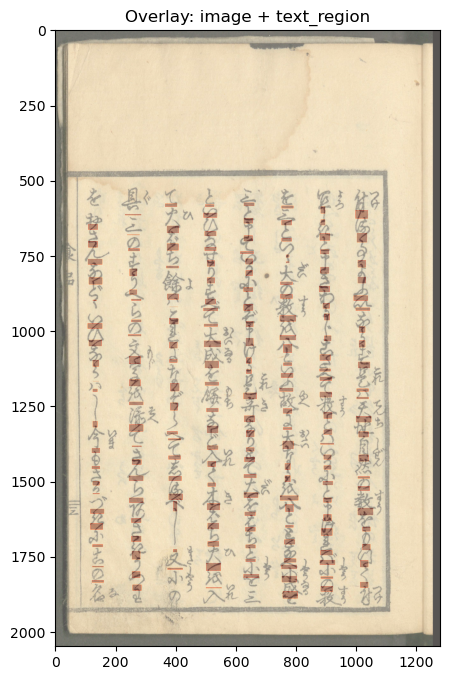

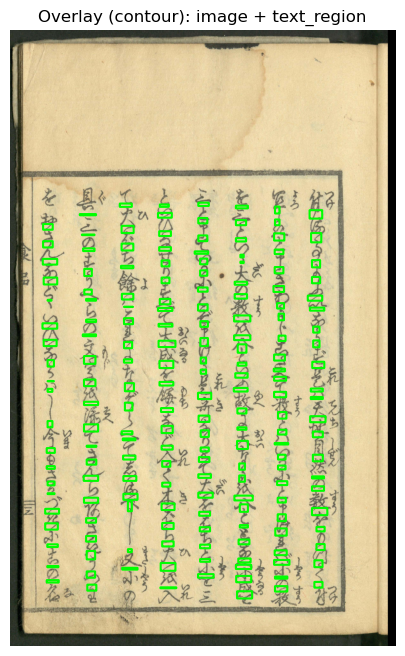

In [7]:
# ...existing code...
import numpy as np
from matplotlib import pyplot as plt
data = train_dataset[16]  # 1サンプル取得
img = data["image"].permute(1, 2, 0).detach().cpu().numpy()         # (H,W,3) 0..1
mask = data["affinity_mask"].detach().cpu().numpy().astype(np.float32) # (H,W) 0/1

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.imshow(mask, cmap="Reds", alpha=0.35, vmin=0, vmax=1)  # ★重ねる
plt.title("Overlay: image + text_region")
# plt.axis("off")
plt.show()

# （任意）境界線だけ重ねたい場合
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.contour(mask, levels=[0.5], colors="lime", linewidths=1.5)      # ★輪郭
plt.title("Overlay (contour): image + text_region")
plt.axis("off")
plt.show()
# ...existing code...

In [3]:
# ...existing code...
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchTransformerSep(nn.Module):
    """
    4層U-Net (Encoder 4段 + Bottleneck + Decoder 4段)
    出力: (B, num_classes, H, W)
    """
    def __init__(
        self,
        img_channels: int = 3,
        base_channels: int = 64,
        num_classes: int = 1,
    ):
        super().__init__()

        def conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.enc1 = conv_block(img_channels, base_channels)          # 1x
        self.enc2 = conv_block(base_channels, base_channels * 2)     # 1/2
        self.enc3 = conv_block(base_channels * 2, base_channels * 4) # 1/4
        self.enc4 = conv_block(base_channels * 4, base_channels * 8) # 1/8

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(base_channels * 8, base_channels * 16)  # 1/16

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = conv_block(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = conv_block(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = conv_block(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = conv_block(base_channels * 2, base_channels)

        self.head = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.enc1(img)           # (B, C, H, W)
        e2 = self.enc2(self.pool(e1)) # (B, 2C, H/2, W/2)
        e3 = self.enc3(self.pool(e2)) # (B, 4C, H/4, W/4)
        e4 = self.enc4(self.pool(e3)) # (B, 8C, H/8, W/8)

        # Bottleneck
        b = self.bottleneck(self.pool(e4))  # (B, 16C, H/16, W/16)

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        logits = self.head(d1)
        return logits

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchTransformerSep(nn.Module):
    def __init__(self, img_channels=3, big_patch_size=256, vit_patch_size=16,
                 d_model=256, nhead=8, num_layers=4, num_classes=2):
        super().__init__()
        self.big_patch_size = big_patch_size     # 256
        self.vit_patch_size = vit_patch_size     # 16
        self.img_channels = img_channels

        inner_patch_dim = img_channels * vit_patch_size * vit_patch_size
        self.patch_embed = nn.Linear(inner_patch_dim, d_model)

        max_tokens = (big_patch_size // vit_patch_size) ** 2  # 256
        self.pos_embed = nn.Parameter(torch.zeros(1, max_tokens, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ★ここが「出力層の形」: Cクラスぶん出す
        self.head = nn.Conv2d(d_model, num_classes, kernel_size=1)

    def forward(self, img):
        """
        img: (B, 3, H, W), H,W は 256 の倍数を想定
        return: logits: (B, C, H, W)
        """
        B, C, H, W = img.shape
        P = self.big_patch_size      # 256
        p = self.vit_patch_size      # 16

        assert H % P == 0 and W % P == 0, "H,W は big_patch_size(256) の倍数を想定"
        nH_big = H // P
        nW_big = W // P
        n_big = nH_big * nW_big

        # 1) 256×256 タイル化
        x = img.unfold(2, P, P).unfold(3, P, P)                 # (B,C,nH,nW,P,P)
        x = x.permute(0, 2, 3, 1, 4, 5).contiguous()            # (B,nH,nW,C,P,P)
        x = x.view(B * n_big, C, P, P)                          # (B*n_big,C,256,256)

        # 2) タイル内を 16×16 パッチ(=token)化
        n_h_inner = P // p                                       # 16
        n_w_inner = P // p                                       # 16
        N_inner = n_h_inner * n_w_inner                          # 256

        x = x.unfold(2, p, p).unfold(3, p, p)                    # (B*n_big,C,16,16,p,p)
        x = x.contiguous().view(B * n_big, C, N_inner, p * p)    # (B*n_big,C,256,256)
        x = x.permute(0, 2, 1, 3).contiguous().view(B * n_big, N_inner, -1)

        # 3) Transformer
        x = self.patch_embed(x)                                  # (B*n_big,256,d_model)
        x = x + self.pos_embed[:, :N_inner, :]
        x = self.encoder(x)

        # 4) 16×16 に戻して -> Cクラスlogits -> 256×256へ拡大
        x = x.view(B * n_big, n_h_inner, n_w_inner, -1).permute(0, 3, 1, 2).contiguous()
        logits_small = self.head(x)                               # (B*n_big,C,16,16)
        logits_tile = F.interpolate(logits_small, size=(P, P), mode="bilinear", align_corners=False)

        # 5) タイルを敷き詰めて (B,C,H,W)
        logits_tile = logits_tile.view(B, nH_big, nW_big, -1, P, P)
        logits = logits_tile.permute(0, 3, 1, 4, 2, 5).contiguous().view(B, -1, H, W)
        return logits


def masked_bce_onehot_loss(logits_bchw: torch.Tensor, target_bchw: torch.Tensor) -> torch.Tensor:
    """
    target は one-hot (B,C,H,W)。未ラベル画素は全0。
    未ラベル画素（target.sum(C)==0）は損失から除外する。
    """
    # (B,1,H,W)
    labeled = (target_bchw.sum(dim=1, keepdim=True) > 0).float()

    loss_map = F.binary_cross_entropy_with_logits(
        logits_bchw, target_bchw, reduction="none"
    )  # (B,C,H,W)

    loss_map = loss_map * labeled  # broadcast
    denom = (labeled.sum() * logits_bchw.size(1)).clamp_min(1.0)
    return loss_map.sum() / denom


def bce_onehot_with_background(
    logits_bchw: torch.Tensor,
    target_bchw: torch.Tensor,
    bg_weight: float = 0.05,   # 背景の重み（0<bg_weight<=1）。小さくするほど背景の影響を弱める
) -> torch.Tensor:
    """
    target: one-hot (B,C,H,W)
      - 文字(ラベルあり)画素: どれか1チャネルが1（想定）
      - 背景画素: 全チャネル0（重要）
    """
    # (B,1,H,W) 背景=1, 前景=0
    is_bg = (target_bchw.sum(dim=1, keepdim=True) == 0).float()
    is_fg = 1.0 - is_bg

    # (B,1,H,W) の画素重み（Cへbroadcastされる）
    w = is_fg + bg_weight * is_bg

    loss_map = F.binary_cross_entropy_with_logits(
        logits_bchw, target_bchw, reduction="none"
    )  # (B,C,H,W)

    loss_map = loss_map * w

    denom = (w.sum() * logits_bchw.size(1)).clamp_min(1.0)
    return loss_map.sum() / denom


# 学習させる

In [5]:
# ...existing code...
import os
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# -------------------------
# DataLoader（Windowsなら num_workers=0 推奨）
# -------------------------
train_loader = DataLoader(
    train_dataset, batch_size=1, shuffle=True, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True
)

# -------------------------
# Model / Optim
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = PatchTransformerSep(
#     img_channels=3,
#     big_patch_size=256,
#     vit_patch_size=16,
#     d_model=256,
#     nhead=8,
#     num_layers=4,
#     num_classes=1,   # ★text_region用: 1チャネル出力
# ).to(device)
model = PatchTransformerSep().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# AMP（CUDAのときだけ有効）
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# -------------------------
# Checkpoint settings
# -------------------------
ckpt_dir = Path(r"c:\Users\kotat\MyPrograms\MyKuzushiji\Glue_Craft\test\checkpoints1_1")
ckpt_dir.mkdir(parents=True, exist_ok=True)

num_epochs = 100
best_test_loss = float("inf")
history = {"train_loss": [], "test_loss": []}

def _bce_text_region_loss(
    logits: torch.Tensor,
    target_mask: torch.Tensor,
    *,
    bg_weight: float = 0.05,  # 背景(0)の重み。小さいほど背景の影響を弱める
) -> torch.Tensor:
    """
    logits: (B,1,H,W)
    target_mask: (B,1,H,W) float {0,1}
    """
    # 背景=1, 前景=0 のマスク（1ch想定）
    is_bg = (target_mask <= 0.5).float()
    is_fg = 1.0 - is_bg

    # 前景は1、背景はbg_weight
    w = is_fg + bg_weight * is_bg  # (B,1,H,W)

    loss_map = F.binary_cross_entropy_with_logits(logits, target_mask, reduction="none")  # (B,1,H,W)
    loss_map = loss_map * w

    denom = w.sum().clamp_min(1.0)
    return loss_map.sum() / denom

for epoch in range(1, num_epochs + 1):
    # -------------------------
    # Train
    # -------------------------
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    for batch in train_loader:
        img = batch["image"].to(device, non_blocking=True)  # (B,3,H,W)
        mask = batch["text_region"].to(device, non_blocking=True).unsqueeze(1)  # (B,1,H,W)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(img)  # (B,1,H,W)
            loss = _bce_text_region_loss(logits, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = img.size(0)
        train_loss_sum += loss.item() * bs
        train_count += bs

    train_loss = train_loss_sum / max(train_count, 1)

    # -------------------------
    # Test (validation)
    # -------------------------
    model.eval()
    test_loss_sum = 0.0
    test_count = 0

    with torch.no_grad():
        for batch in test_loader:
            img = batch["image"].to(device, non_blocking=True)
            mask = batch["text_region"].to(device, non_blocking=True).unsqueeze(1)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(img)
                loss = _bce_text_region_loss(logits, mask)

            bs = img.size(0)
            test_loss_sum += loss.item() * bs
            test_count += bs

    test_loss = test_loss_sum / max(test_count, 1)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"[Epoch {epoch:03d}/{num_epochs}] train_loss={train_loss:.6f}  test_loss={test_loss:.6f}")

    # -------------------------
    # Save checkpoint (every epoch)
    # -------------------------
    ckpt_path = ckpt_dir / f"patch_transformer_sep_epoch{epoch:03d}.pth"
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "test_loss": test_loss,
            "history": history,
            "config": {
                "num_classes": 1,
                "big_patch_size": 256,
                "vit_patch_size": 16,
                "canvas_width": getattr(train_dataset, "canvas_width", None),
                "patch_size": getattr(train_dataset, "patch_size", None),
            },
        },
        ckpt_path,
    )

    # Best checkpoint
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_path = ckpt_dir / "patch_transformer_sep_best.pth"
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "test_loss": test_loss,
                "history": history,
            },
            best_path,
        )

print("done. best_test_loss =", best_test_loss)
# ...existing code...

KeyError: 'text_region'